# Predicción de Edad en Abalones usando Redes Neuronales (Regresión)

**Objetivo:** El propósito de este notebook es resolver un problema de **regresión** utilizando el **Abalone Dataset**. 
Buscamos predecir la variable `Rings` (cantidad de anillos físicos en el caparazón de un abalón) a partir de diversas medidas físicas (como longitud, diámetro, pesos, sexo, etc.). 

La cantidad de anillos se utiliza para determinar la edad del espécimen (Edad = Rings + 1.5 años).

In [85]:
# Delio Fernando Palacios Viafara - 115782
# Johan Camilo Balanta Santacruz - 115778
%pip install ucimlrepo

In [86]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from ucimlrepo import fetch_ucirepo
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_percentage_error, r2_score
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers.schedules import ExponentialDecay

In [87]:
#Cargar dataset
abalone = fetch_ucirepo(id=1)
X = abalone.data.features 
y = abalone.data.targets 

print(abalone.variables)

             name     role         type demographic  \
0             Sex  Feature  Categorical        None   
1          Length  Feature   Continuous        None   
2        Diameter  Feature   Continuous        None   
3          Height  Feature   Continuous        None   
4    Whole_weight  Feature   Continuous        None   
5  Shucked_weight  Feature   Continuous        None   
6  Viscera_weight  Feature   Continuous        None   
7    Shell_weight  Feature   Continuous        None   
8           Rings   Target      Integer        None   

                   description  units missing_values  
0         M, F, and I (infant)   None             no  
1    Longest shell measurement     mm             no  
2      perpendicular to length     mm             no  
3           with meat in shell     mm             no  
4                whole abalone  grams             no  
5               weight of meat  grams             no  
6  gut weight (after bleeding)  grams             no  
7        

### Exploración de los Datos Originales
Antes de aplicar transformaciones a los datos, observemos cómo están distribuidos para entender por qué son necesarios los pasos de estandarización y transformación (One-Hot Encoding).

A continuación mostramos un resumen estadístico y un diagrama de cajas (boxplot) de las variables numéricas.


Rango (Máximo - Mínimo) de las características numéricas:


,Rango
Length,0.7400
Diameter,0.5950
Height,1.1300
Whole_weight,2.8235
Shucked_weight,1.4870
Viscera_weight,0.7595
Shell_weight,1.0035


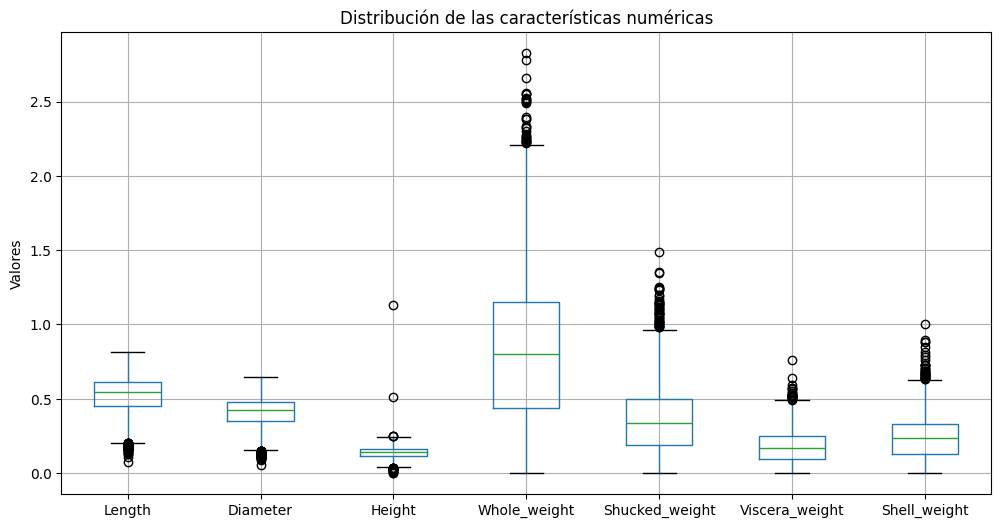

In [88]:
# Resumen estadístico
# display(X.describe())

# Calcular y mostrar el rango de las variables numéricas
print("\nRango (Máximo - Mínimo) de las características numéricas:")
rangos = X.select_dtypes(include=[np.number]).max() - X.select_dtypes(include=[np.number]).min()
display(rangos.to_frame(name='Rango'))

# Visualizar la distribución/escala de las variables numéricas
plt.figure(figsize=(12, 6))
X.select_dtypes(include=[np.number]).boxplot()
plt.title("Distribución de las características numéricas")
plt.ylabel("Valores")
plt.show()

Como se puede apreciar en el gráfico, hay características que manejan escalas distintas. Las Redes Neuronales son muy sensibles a estas diferencias, por lo tanto, esto justifica el uso posterior de un **StandardScaler**.

Además de las variables numéricas, tenemos la variable **categórica** `Sex`:

In [89]:
# Ver valores de la variable categórica
print("Frecuencia de las clases en la columna Sex:\n", X['Sex'].value_counts())

Frecuencia de las clases en la columna Sex:
 Sex
M    1528
I    1342
F    1307
Name: count, dtype: int64


### Preprocesamiento de Datos
Dado que una red neuronal solo acepta entradas numéricas, necesitamos convertir los caracteres de texto (`M`, `F`, `I` de 'Sex') a variables numéricas.

In [100]:
# Transformar la variable categórica Sex en variables dummy
X_encoded = pd.get_dummies(X, columns=['Sex'])

print("Datos DESPUÉS de transformar la variable categórica:")
display(X_encoded.head())

Datos DESPUÉS de transformar la variable categórica:


,Length,Diameter,Height,Whole_weight,Shucked_weight,Viscera_weight,Shell_weight,Sex_F,Sex_I,Sex_M
0,0.455,0.365,0.095,0.5140,0.2245,0.1010,0.150,False,False,True
1,0.350,0.265,0.090,0.2255,0.0995,0.0485,0.070,False,False,True
2,0.530,0.420,0.135,0.6770,0.2565,0.1415,0.210,True,False,False
3,0.440,0.365,0.125,0.5160,0.2155,0.1140,0.155,False,False,True
4,0.330,0.255,0.080,0.2050,0.0895,0.0395,0.055,False,True,False


Ahora, para tener todo listo para ser entregado a la red, tomamos nuestros datos transformados y procedemos a:
1. **Separarlos en subconjuntos (Train / Test)** para luego evaluar si el modelo generalizó o no
2. **Estandarizar (escalar)** las características basándonos en la media y desviación del Train, llevando todas a la misma escala visualizada anteriormente.

In [99]:
X_array = X_encoded.values
y_array = y.values.ravel() # Asegurar que y sea un array unidimensional numérico

# Dividir en conjunto de entrenamiento y prueba (80% entrenamiento, 20% prueba)
X_train, X_test, y_train, y_test = train_test_split(X_array, y_array, test_size=0.2, random_state=42, shuffle=True)

# Estandarizar las características 
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print("Forma de X_train (Después de dividir):", X_train.shape)
print("Forma de X_test (Después de dividir):", X_test.shape)

Forma de X_train (Después de dividir): (3341, 10)
Forma de X_test (Después de dividir): (836, 10)


### Construcción y Entrenamiento del Modelo MLP
Con los datos escalados y totalmente numéricos, definimos una red neuronal multicapa con Keras. Se utiliza el optimizador Adam y Hubber loss como función de costo. Utilizamos 1 capa de salida lineal debido a la naturaleza de regresión del problema.

In [101]:
model = Sequential([
    Dense(128, activation='relu', input_shape=(X_train.shape[1],)),
    Dense(64, activation='relu'), 
    # Dense(16, activation='relu'),
    Dense(1, activation='linear')  # Capa de salida lineal para predicciones continuas
])


# Refinar la busqueda 
lr = ExponentialDecay(
    initial_learning_rate=0.001,
    decay_steps=100,
    decay_rate=0.9 # reduce 10% el lr cada 100 pasos
)

# Compilar el modelo
model.compile(optimizer=Adam(learning_rate=lr),
              loss='mse', 
              metrics=['mae'])


# Detener el entrenamiento si el MAE de validación no mejora tras 20 épocas
early_stop = EarlyStopping(monitor='val_mae',
                            patience=20,
                            restore_best_weights=True,
                            verbose=1)

# Entrenar el modelo
history = model.fit(X_train, y_train,
                    epochs=150,
                    batch_size=32,
                    validation_split=0.3,  # Usar parte del entrenamiento para validación
                    callbacks=[early_stop],
                    verbose=1)

Epoch 1/150


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


74/74 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - loss: 57.8908 - mae: 6.4470 - val_loss: 18.5057 - val_mae: 3.3380
Epoch 2/150
74/74 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 12.6109 - mae: 2.5281 - val_loss: 6.8920 - val_mae: 1.9006
Epoch 3/150
74/74 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 7.1873 - mae: 1.8270 - val_loss: 5.1680 - val_mae: 1.6387
Epoch 4/150
74/74 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 6.1793 - mae: 1.7195 - val_loss: 4.6095 - val_mae: 1.5282
Epoch 5/150
74/74 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 5.7697 - mae: 1.6713 - val_loss: 4.5473 - val_mae: 1.4968
Epoch 6/150
74/74 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 5.5452 - mae: 1.6533 - val_loss: 4.4265 - val_mae: 1.4665
Epoch 7/150
74/74 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 5.3811 - mae: 1.6393 - val_loss: 4.4200 - val_mae: 1.5132
Epoch 8/150
74/74 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 5.2212 - mae: 1.6174 - val_loss: 4.2073 - val_mae: 1.4502
Epoch 9/150
74/74 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 5.1553 - mae:

### Evaluación del Modelo
Evaluamos el modelo utilizando el conjunto de prueba para observar qué tal generaliza con datos que no han sido vistos durante el entrenamiento. 

Extraemos las predicciones y calculamos las principales métricas de error y desempeño para regresión , las cuales nos permitirán validar la calidad y la magnitud de desviación de nuestras estimaciones.

In [102]:
# Evaluar el modelo en el conjunto de prueba
eval_results = model.evaluate(X_test, y_test, verbose=0)
test_loss = eval_results[0] # MSE
test_mae = eval_results[1]  # MAE

print(f"(MSE) Error cuadrático medio: {test_loss:.2f}")
print(f"(MAE) Error absoluto medio: {test_mae:.2f} anillos")

# Calcular el RMSE a partir del MSE
rmse = np.sqrt(test_loss)
print(f"(RMSE) Raíz del error cuadrático medio: {rmse:.2f}")

# Realizar predicciones en el conjunto de prueba
y_pred = model.predict(X_test)

# Calcular MAPE
mape = mean_absolute_percentage_error(y_test, y_pred)
print(f"(MAPE) Mean Absolute Percentage Error: {mape * 100:.2f}%")

# Calcular R² (Coeficiente de determinación)
r2 = r2_score(y_test, y_pred)
print(f"(R²) Coeficiente de determinación: {r2:.3f}")

(MSE) Error cuadrático medio: 4.76
(MAE) Error absoluto medio: 1.56 anillos
(RMSE) Raíz del error cuadrático medio: 2.18
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
(MAPE) Mean Absolute Percentage Error: 15.33%
(R²) Coeficiente de determinación: 0.561


### Interpretación de las Métricas

Para evaluar correctamente un problema de **regresión**, estas son las métricas aplicables:

1. **MAE (Error Absoluto Medio)**: Es la métrica más "humana". Si es ~1.5, significa que el modelo falla, en promedio, por 1.5 anillos.

2. **MSE (Error Cuadrático Medio)** y **RMSE (Raíz del Error Cuadrático Medio)**: El MSE penaliza fuertemente a los errores grandes (elevándolos al cuadrado). El RMSE nos devuelve ese error a nuestra escala (anillos), siendo casi siempre más alto que el MAE. Si el RMSE es mucho más alto que el MAE, significa que el modelo comete errores enormes en unos pocos especímenes.

3. **MAPE (Error Porcentual)**: Nos ayuda a tener una perspectiva de la magnitud del error. Un MAPE del 15% significa que la predicción suele desviarse un 15% de la edad biológica real del abalón.

4. **$R^2$ (Coeficiente de Determinación)**: Indica **qué porcentaje de la variabilidad del target (cantidad de anillos) es capaz de explicar el modelo a partir de todas las características de entrada**. Un modelo perfecto tendría $1.0$, un modelo que siempre adivine tendría $0.0$. Para este dataset específico (muy complejo biológicamente), lograr un $R^2 \approx 0.55\ -\ 0.60$ es el estándar de oro (estado del arte).

### Visualización de Resultados


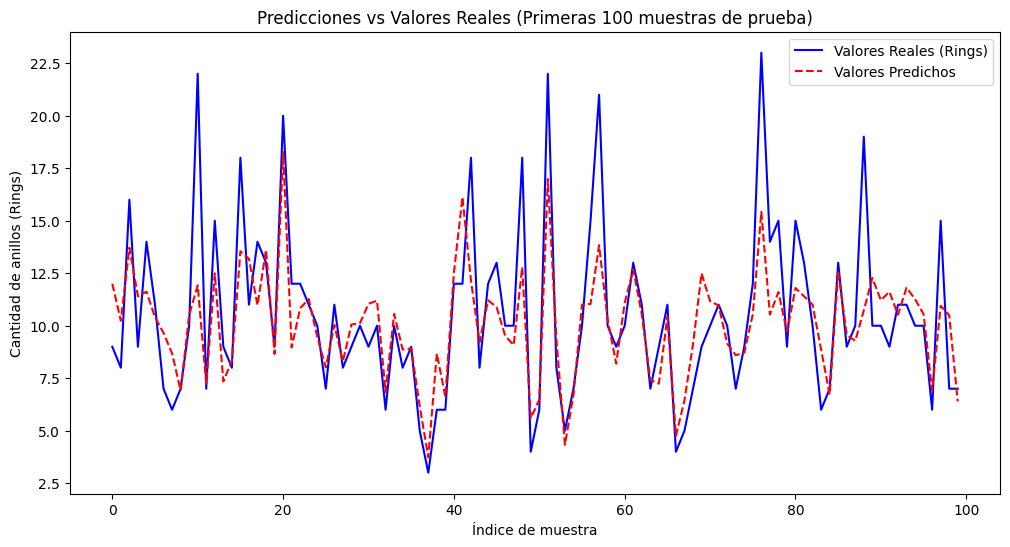

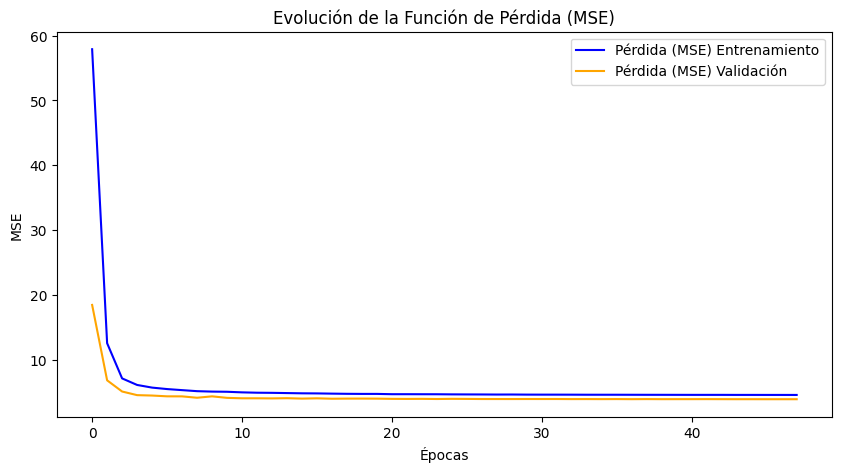

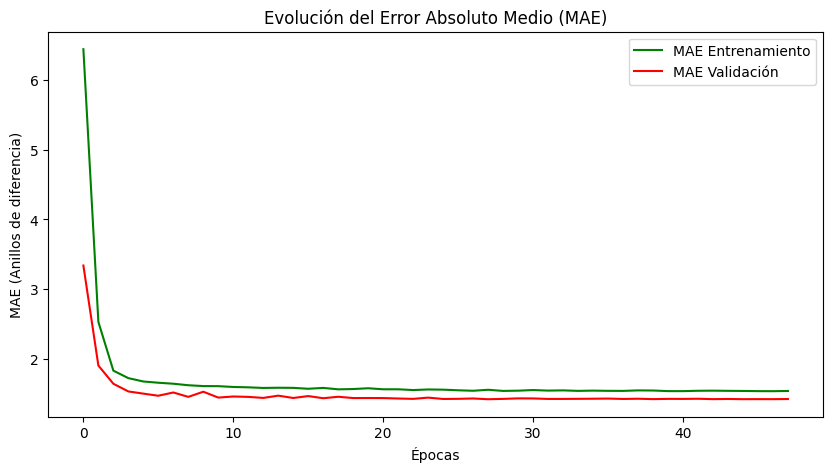

In [103]:
# Graficar las predicciones vs los valores reales (Mostramos solo los primeros 100 para observar mejor)
plt.figure(figsize=(12, 6))
plt.plot(y_test[:100], label='Valores Reales (Rings)', color='blue')
plt.plot(y_pred[:100], label='Valores Predichos', color='red', linestyle='--')
plt.title('Predicciones vs Valores Reales (Primeras 100 muestras de prueba)')
plt.xlabel('Índice de muestra')
plt.ylabel('Cantidad de anillos (Rings)')
plt.legend()
plt.show()

# Graficar la pérdida de Entrenamiento y Validación
plt.figure(figsize=(10, 5))
# history.history['loss'] siempre guarda la función de costo principal
plt.plot(history.history['loss'], label='Pérdida (MSE) Entrenamiento', color='blue')
plt.plot(history.history['val_loss'], label='Pérdida (MSE) Validación', color='orange')
plt.title('Evolución de la Función de Pérdida (MSE)')
plt.xlabel('Épocas')
plt.ylabel('MSE')
plt.legend()
plt.show()

# Graficar la métrica MAE (Mean Absolute Error) de Entrenamiento y Validación
plt.figure(figsize=(10, 5))
plt.plot(history.history['mae'], label='MAE Entrenamiento', color='green')
plt.plot(history.history['val_mae'], label='MAE Validación', color='red')
plt.title('Evolución del Error Absoluto Medio (MAE)')
plt.xlabel('Épocas')
plt.ylabel('MAE (Anillos de diferencia)')
plt.legend()
plt.show()
